# HW14: Intro to NN, Regression

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from keras.callbacks import LearningRateScheduler, ReduceLROnPlateau
from keras.callbacks import History, Callback
from keras.optimizers import SGD, Adam
from keras.wrappers.scikit_learn import KerasRegressor
from keras import optimizers
from keras import backend as K
from sklearn.datasets import load_boston

Using TensorFlow backend.


In [2]:
%load_ext pycodestyle_magic

In [3]:
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

## Import

In [4]:
def load_housing_data_frame(verbose=True):
    raw = load_boston()
    data_frame = pd.DataFrame(raw.data, columns=raw.feature_names)
    data_frame['PRICE'] = raw.target
    if verbose:
        print(raw.DESCR)
    return data_frame

In [5]:
df = load_housing_data_frame()

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### Splitting and standardizing the data

In [7]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
def scale(data_frame, scaler):
    data_frame = pd.DataFrame(
        data=scaler.transform(data_frame.to_numpy()),
        columns=data_frame.columns,
        index=data_frame.index
    )
    return data_frame

def xy_split(data_frame):
    x = data_frame.drop(['PRICE'], axis=1)
    y = data_frame['PRICE']
    return x, y

In [9]:
X_train, y_train = xy_split(train_data)
X_test, y_test = xy_split(test_data)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scale(X_train, scaler)
X_test = scale(X_test, scaler)

## Model

$R^{2}$ metric

In [10]:
def coeff_determination(y_true, y_pred):
    SS_res =  K.sum(K.square( y_true-y_pred )) 
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) ) 
    return ( 1 - SS_res/(SS_tot + K.epsilon()) )

In [11]:
def create_model(nodes=64, opt='adam',
                 act0='relu', act1='relu', drop=0):

    model = Sequential()
    model.add(Dense(nodes, input_shape=(X_train.shape[1], ),
                    activation=act0))
    model.add(Dropout(drop))
    model.add(Dense(nodes, activation=act1))
    model.add(Dense(1, activation="linear"))

    model.compile(
    loss='mean_squared_error',
    optimizer=opt,
    metrics=[coeff_determination]
    )

    return model

In [12]:
batch = 32
epoch = 100
split = 0.2
sh = True

In [13]:
model_CV = KerasRegressor(build_fn=create_model, epochs=epoch, 
                           batch_size=batch, verbose=1)

In [14]:
param_grid = {
    'nodes' : [64, 128, 256],
    'act0' : ['relu', 'tanh'],
    'drop' : [0., 0.1, 0.2, 0.5],
    'act1' : ['relu', 'tanh'],
    'opt' : ['adam']
}

In [15]:
grid = RandomizedSearchCV(estimator=model_CV, param_distributions=param_grid,
                          cv=5, verbose=100, scoring='r2')
grid_result = grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] opt=adam, nodes=256, drop=0.5, act1=relu, act0=tanh .............
Epoch 1/100
323/323 [==============================] - 0s 1ms/step - loss: 574.6917 - coeff_determination: -5.7372
Epoch 2/100
323/323 [==============================] - 0s 118us/step - loss: 456.5476 - coeff_determination: -4.6488
Epoch 3/100
323/323 [==============================] - 0s 136us/step - loss: 287.3492 - coeff_determination: -5.0182
Epoch 4/100
323/323 [==============================] - 0s 138us/step - loss: 152.4624 - coeff_determination: -0.7654
Epoch 5/100
323/323 [==============================] - 0s 109us/step - loss: 107.5124 - coeff_determination: -0.8313
Epoch 6/100
323/323 [==============================] - 0s 151us/step - loss: 81.1510 - coeff_determination: -52.0975
Epoch 7/100
323/323 [==============================] - 0s 130us/step - loss: 59.8182 - 

323/323 [==============================] - 0s 113us/step - loss: 19.0545 - coeff_determination: 0.7645
Epoch 38/100
323/323 [==============================] - 0s 111us/step - loss: 20.3840 - coeff_determination: 0.7153
Epoch 39/100
323/323 [==============================] - 0s 117us/step - loss: 16.7259 - coeff_determination: 0.5090
Epoch 40/100
323/323 [==============================] - 0s 130us/step - loss: 18.0934 - coeff_determination: 0.7007
Epoch 41/100
323/323 [==============================] - 0s 121us/step - loss: 16.7646 - coeff_determination: 0.7514
Epoch 42/100
323/323 [==============================] - 0s 102us/step - loss: 16.0879 - coeff_determination: 0.7933
Epoch 43/100
323/323 [==============================] - 0s 112us/step - loss: 16.8087 - coeff_determination: 0.7747
Epoch 44/100
323/323 [==============================] - 0s 158us/step - loss: 16.6272 - coeff_determination: 0.7705
Epoch 45/100
323/323 [==============================] - 0s 114us/step - loss: 16.2005

323/323 [==============================] - 0s 124us/step - loss: 14.6981 - coeff_determination: 0.7952
Epoch 76/100
323/323 [==============================] - 0s 133us/step - loss: 13.5859 - coeff_determination: 0.6609
Epoch 77/100
323/323 [==============================] - 0s 152us/step - loss: 15.5573 - coeff_determination: 0.3461
Epoch 78/100
323/323 [==============================] - 0s 116us/step - loss: 13.7101 - coeff_determination: 0.7456
Epoch 79/100
323/323 [==============================] - 0s 131us/step - loss: 13.4516 - coeff_determination: 0.8293
Epoch 80/100
323/323 [==============================] - 0s 146us/step - loss: 15.0054 - coeff_determination: 0.8125
Epoch 81/100
323/323 [==============================] - 0s 134us/step - loss: 15.4214 - coeff_determination: 0.8089
Epoch 82/100
323/323 [==============================] - 0s 132us/step - loss: 13.3241 - coeff_determination: 0.7103
Epoch 83/100
323/323 [==============================] - 0s 128us/step - loss: 14.7687

324/324 [==============================] - 0s 159us/step - loss: 38.4261 - coeff_determination: 0.4726
Epoch 12/100
324/324 [==============================] - 0s 115us/step - loss: 35.7386 - coeff_determination: 0.5781
Epoch 13/100
324/324 [==============================] - 0s 111us/step - loss: 33.3063 - coeff_determination: 0.5586
Epoch 14/100
324/324 [==============================] - 0s 93us/step - loss: 31.6087 - coeff_determination: 0.6382
Epoch 15/100
324/324 [==============================] - 0s 98us/step - loss: 33.9481 - coeff_determination: 0.6147
Epoch 16/100
324/324 [==============================] - 0s 98us/step - loss: 31.8482 - coeff_determination: 0.1946
Epoch 17/100
324/324 [==============================] - 0s 92us/step - loss: 29.3076 - coeff_determination: 0.5651
Epoch 18/100
324/324 [==============================] - 0s 107us/step - loss: 27.7214 - coeff_determination: 0.5654
Epoch 19/100
324/324 [==============================] - 0s 127us/step - loss: 29.2606 - c

323/323 [==============================] - 0s 97us/step - loss: 9.4816 - coeff_determination: 0.8640
Epoch 50/100
323/323 [==============================] - 0s 97us/step - loss: 9.9336 - coeff_determination: 0.8958
Epoch 51/100
323/323 [==============================] - 0s 99us/step - loss: 8.7124 - coeff_determination: 0.8921
Epoch 52/100
323/323 [==============================] - 0s 101us/step - loss: 8.8194 - coeff_determination: 0.8914
Epoch 53/100
323/323 [==============================] - 0s 145us/step - loss: 9.0197 - coeff_determination: 0.8851
Epoch 54/100
323/323 [==============================] - 0s 143us/step - loss: 8.3761 - coeff_determination: 0.8621
Epoch 55/100
323/323 [==============================] - 0s 135us/step - loss: 8.1230 - coeff_determination: 0.9071
Epoch 56/100
323/323 [==============================] - 0s 106us/step - loss: 8.0218 - coeff_determination: 0.8735
Epoch 57/100
323/323 [==============================] - 0s 106us/step - loss: 7.7677 - coeff_det

...

323/323 [==============================] - 0s 141us/step - loss: 53.0676 - coeff_determination: 0.4133
Epoch 39/100
323/323 [==============================] - 0s 159us/step - loss: 55.1301 - coeff_determination: 0.2488
Epoch 40/100
323/323 [==============================] - 0s 137us/step - loss: 53.7179 - coeff_determination: -0.1538
Epoch 41/100
323/323 [==============================] - 0s 132us/step - loss: 54.0635 - coeff_determination: 0.3265
Epoch 42/100
323/323 [==============================] - 0s 139us/step - loss: 50.7410 - coeff_determination: 0.3522
Epoch 43/100
323/323 [==============================] - 0s 128us/step - loss: 53.7366 - coeff_determination: 0.4287
Epoch 44/100
323/323 [==============================] - 0s 154us/step - loss: 51.2105 - coeff_determination: 0.4263
Epoch 45/100
323/323 [==============================] - 0s 120us/step - loss: 52.6418 - coeff_determination: 0.4108
Epoch 46/100
323/323 [==============================] - 0s 132us/step - loss: 50.788

323/323 [==============================] - 0s 119us/step - loss: 35.6150 - coeff_determination: 0.5033
Epoch 77/100
323/323 [==============================] - 0s 175us/step - loss: 36.4848 - coeff_determination: 0.5397
Epoch 78/100
323/323 [==============================] - 0s 158us/step - loss: 37.6773 - coeff_determination: 0.5286
Epoch 79/100
323/323 [==============================] - 0s 161us/step - loss: 36.7905 - coeff_determination: 0.5785
Epoch 80/100
323/323 [==============================] - 0s 126us/step - loss: 36.3920 - coeff_determination: -2.5783
Epoch 81/100
323/323 [==============================] - 0s 142us/step - loss: 36.6262 - coeff_determination: 0.5277
Epoch 82/100
323/323 [==============================] - 0s 147us/step - loss: 33.9984 - coeff_determination: 0.4655
Epoch 83/100
323/323 [==============================] - 0s 150us/step - loss: 34.6790 - coeff_determination: 0.5875
Epoch 84/100
323/323 [==============================] - 0s 139us/step - loss: 33.972

323/323 [==============================] - 0s 125us/step - loss: 358.4793 - coeff_determination: -4.1991
Epoch 12/100
323/323 [==============================] - 0s 141us/step - loss: 315.3581 - coeff_determination: -35.3693
Epoch 13/100
323/323 [==============================] - 0s 154us/step - loss: 276.9385 - coeff_determination: -5.7080
Epoch 14/100
323/323 [==============================] - 0s 150us/step - loss: 244.4584 - coeff_determination: -2.5169
Epoch 15/100
323/323 [==============================] - 0s 137us/step - loss: 206.5532 - coeff_determination: -1.7772
Epoch 16/100
323/323 [==============================] - 0s 144us/step - loss: 165.8396 - coeff_determination: -1.3428
Epoch 17/100
323/323 [==============================] - 0s 143us/step - loss: 152.5594 - coeff_determination: -1.2197
Epoch 18/100
323/323 [==============================] - 0s 131us/step - loss: 126.3134 - coeff_determination: -0.8742
Epoch 19/100
323/323 [==============================] - 0s 167us/ste

324/324 [==============================] - 0s 143us/step - loss: 48.4397 - coeff_determination: 0.4457
Epoch 49/100
324/324 [==============================] - 0s 135us/step - loss: 49.6217 - coeff_determination: 0.4519
Epoch 50/100
324/324 [==============================] - 0s 139us/step - loss: 45.8765 - coeff_determination: 0.2658
Epoch 51/100
324/324 [==============================] - 0s 138us/step - loss: 48.7416 - coeff_determination: 0.3516
Epoch 52/100
324/324 [==============================] - 0s 134us/step - loss: 52.3725 - coeff_determination: 0.4288
Epoch 53/100
324/324 [==============================] - 0s 151us/step - loss: 46.9933 - coeff_determination: 0.4913
Epoch 54/100
324/324 [==============================] - 0s 136us/step - loss: 44.5917 - coeff_determination: 0.5079
Epoch 55/100
324/324 [==============================] - 0s 131us/step - loss: 46.5113 - coeff_determination: 0.4199
Epoch 56/100
324/324 [==============================] - 0s 126us/step - loss: 47.7462

404/404 [==============================] - 0s 111us/step - loss: 4.5447 - coeff_determination: 0.9397
Epoch 88/100
404/404 [==============================] - 0s 102us/step - loss: 4.5677 - coeff_determination: 0.9449
Epoch 89/100
404/404 [==============================] - 0s 137us/step - loss: 4.3079 - coeff_determination: 0.9457
Epoch 90/100
404/404 [==============================] - 0s 128us/step - loss: 4.5223 - coeff_determination: 0.9414
Epoch 91/100
404/404 [==============================] - 0s 130us/step - loss: 4.1528 - coeff_determination: 0.9471
Epoch 92/100
404/404 [==============================] - 0s 135us/step - loss: 4.6477 - coeff_determination: 0.9349
Epoch 93/100
404/404 [==============================] - 0s 131us/step - loss: 4.3505 - coeff_determination: 0.9472
Epoch 94/100
404/404 [==============================] - 0s 134us/step - loss: 4.1605 - coeff_determination: 0.9482
Epoch 95/100
404/404 [==============================] - 0s 129us/step - loss: 3.9520 - coeff_

In [16]:
grid_result.best_score_

0.8571249411011943

In [17]:
grid_result.best_params_

{'opt': 'adam', 'nodes': 256, 'drop': 0.1, 'act1': 'tanh', 'act0': 'relu'}

In [18]:
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print(f' mean={mean:.4}, std={stdev:.4} using {param}')

 mean=0.8484, std=0.0417 using {'opt': 'adam', 'nodes': 256, 'drop': 0.5, 'act1': 'relu', 'act0': 'tanh'}
 mean=0.8571, std=0.02965 using {'opt': 'adam', 'nodes': 256, 'drop': 0.1, 'act1': 'tanh', 'act0': 'relu'}
 mean=0.8509, std=0.03276 using {'opt': 'adam', 'nodes': 256, 'drop': 0.0, 'act1': 'tanh', 'act0': 'relu'}
 mean=0.8378, std=0.03342 using {'opt': 'adam', 'nodes': 256, 'drop': 0.5, 'act1': 'tanh', 'act0': 'tanh'}
 mean=0.8146, std=0.05285 using {'opt': 'adam', 'nodes': 128, 'drop': 0.5, 'act1': 'tanh', 'act0': 'relu'}
 mean=0.8021, std=0.03956 using {'opt': 'adam', 'nodes': 128, 'drop': 0.5, 'act1': 'tanh', 'act0': 'tanh'}
 mean=0.8421, std=0.03448 using {'opt': 'adam', 'nodes': 128, 'drop': 0.1, 'act1': 'tanh', 'act0': 'relu'}
 mean=0.8198, std=0.03552 using {'opt': 'adam', 'nodes': 64, 'drop': 0.1, 'act1': 'relu', 'act0': 'tanh'}
 mean=0.831, std=0.04767 using {'opt': 'adam', 'nodes': 128, 'drop': 0.5, 'act1': 'relu', 'act0': 'tanh'}
 mean=0.6825, std=0.04384 using {'opt': 

Running the best model for a bit longer

In [46]:
model = create_model(**grid_result.best_params_)

In [47]:
model.summary()

Model: "sequential_57"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_169 (Dense)            (None, 256)               3584      
_________________________________________________________________
dropout_57 (Dropout)         (None, 256)               0         
_________________________________________________________________
dense_170 (Dense)            (None, 256)               65792     
_________________________________________________________________
dense_171 (Dense)            (None, 1)                 257       
Total params: 69,633
Trainable params: 69,633
Non-trainable params: 0
_________________________________________________________________


In [48]:
np.random.seed(42)

history = model.fit(
    X_train,
    y_train,
    batch_size=batch,
    epochs=2*epoch,
    validation_split=split,
    shuffle=sh
    )

Train on 323 samples, validate on 81 samples
Epoch 1/200
323/323 [==============================] - 0s 603us/step - loss: 500.4331 - coeff_determination: -6.0379 - val_loss: 299.7267 - val_coeff_determination: -3.2985
Epoch 2/200
323/323 [==============================] - 0s 123us/step - loss: 253.7069 - coeff_determination: -1.8541 - val_loss: 122.1419 - val_coeff_determination: -0.7561
Epoch 3/200
323/323 [==============================] - 0s 144us/step - loss: 113.2709 - coeff_determination: -0.3834 - val_loss: 53.5787 - val_coeff_determination: 0.2195
Epoch 4/200
323/323 [==============================] - 0s 147us/step - loss: 64.7956 - coeff_determination: -0.0066 - val_loss: 41.6138 - val_coeff_determination: 0.3819
Epoch 5/200
323/323 [==============================] - 0s 154us/step - loss: 52.2947 - coeff_determination: 0.3919 - val_loss: 39.9749 - val_coeff_determination: 0.3951
Epoch 6/200
323/323 [==============================] - 0s 136us/step - loss: 46.1818 - coeff_determ

Epoch 49/200
323/323 [==============================] - 0s 117us/step - loss: 10.4047 - coeff_determination: 0.8793 - val_loss: 14.0802 - val_coeff_determination: 0.7701
Epoch 50/200
323/323 [==============================] - 0s 123us/step - loss: 10.3180 - coeff_determination: 0.8896 - val_loss: 13.3800 - val_coeff_determination: 0.7848
Epoch 51/200
323/323 [==============================] - 0s 123us/step - loss: 9.7238 - coeff_determination: 0.8935 - val_loss: 13.9915 - val_coeff_determination: 0.7703
Epoch 52/200
323/323 [==============================] - 0s 123us/step - loss: 9.5223 - coeff_determination: 0.8807 - val_loss: 13.4826 - val_coeff_determination: 0.7785
Epoch 53/200
323/323 [==============================] - 0s 111us/step - loss: 9.4929 - coeff_determination: 0.8809 - val_loss: 13.1767 - val_coeff_determination: 0.7837
Epoch 54/200
323/323 [==============================] - 0s 125us/step - loss: 9.4688 - coeff_determination: -0.9811 - val_loss: 14.1883 - val_coeff_deter

323/323 [==============================] - 0s 122us/step - loss: 3.6373 - coeff_determination: 0.9526 - val_loss: 8.7824 - val_coeff_determination: 0.8581
Epoch 146/200
323/323 [==============================] - 0s 130us/step - loss: 3.6557 - coeff_determination: 0.9518 - val_loss: 8.3694 - val_coeff_determination: 0.8643
Epoch 147/200
323/323 [==============================] - 0s 124us/step - loss: 4.4586 - coeff_determination: 0.7801 - val_loss: 9.5998 - val_coeff_determination: 0.8512
Epoch 148/200
323/323 [==============================] - 0s 122us/step - loss: 5.2947 - coeff_determination: 0.9283 - val_loss: 10.4620 - val_coeff_determination: 0.8297
Epoch 149/200
323/323 [==============================] - 0s 124us/step - loss: 4.2553 - coeff_determination: 0.9285 - val_loss: 8.0053 - val_coeff_determination: 0.8740
Epoch 150/200
323/323 [==============================] - 0s 126us/step - loss: 4.2209 - coeff_determination: 0.9511 - val_loss: 9.3034 - val_coeff_determination: 0.8521

In [49]:
r2_score(y_test, model.predict(X_test).reshape(-1))

0.8680273719676684

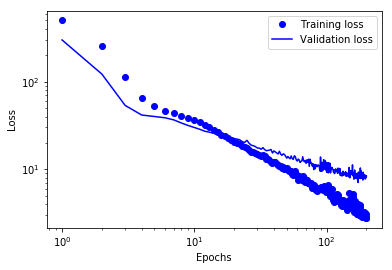

In [50]:
history_dict = history.history
acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

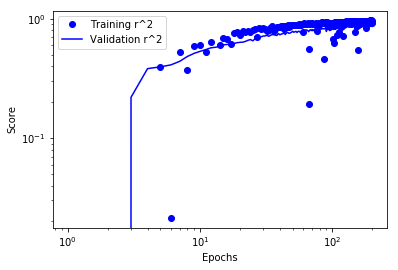

In [51]:
acc_values = history_dict['coeff_determination']
val_acc_values = history_dict['val_coeff_determination']
epochs = range(1, len(acc_values) + 1)
plt.plot(epochs, acc_values, 'bo', label='Training r^2')
plt.plot(epochs, val_acc_values, 'b', label='Validation r^2')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()